# CNN ve Transfer Learning ile Sıtma Hücre Görüntülerinin Sınıflandırılması

Bu projede amaç, mikroskop altında alınmış hücre görüntülerini kullanarak bir hücrenin enfekte (Parasitized) mi yoksa enfekte değil (Uninfected) mi olduğunu otomatik olarak tahmin eden bir görüntü sınıflandırma sistemi geliştirmektir.

Projede önce klasik bir CNN modeli kurulacaktır. Daha sonra aynı veri kümesi üzerinde Transfer Learning yaklaşımı kullanılarak VGG16, VGG19 ve ResNet50 gibi hazır modeller denenecektir.

Bu çalışma sonunda hangi modelin daha iyi sonuç verdiği; doğruluk (accuracy), kayıp (loss), karışıklık matrisi (confusion matrix) ve performans metrikleri üzerinden değerlendirilecektir.

2026-05-06 08:57:08.272335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778057828.504753      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778057828.567412      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778057829.082051      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778057829.082096      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778057829.082099      23 computation_placer.cc:177] computation placer alr

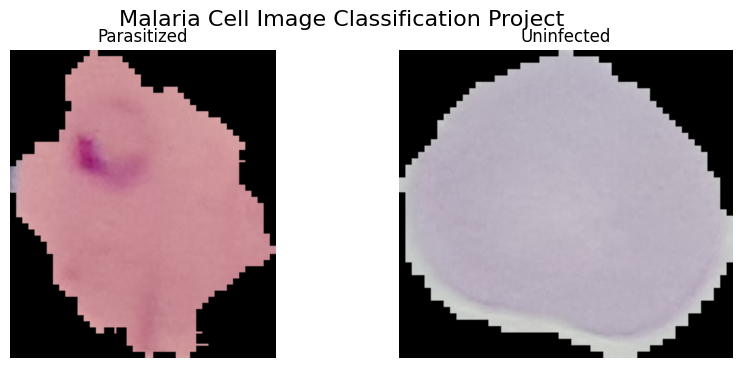

In [1]:
# Şimdi projeyi anlatan örnek hücre görsellerini ekrana basıyoruz

import os, matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

root = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"
p_img = os.path.join(root, "Parasitized", os.listdir(root + "/Parasitized")[0])
u_img = os.path.join(root, "Uninfected", os.listdir(root + "/Uninfected")[0])

plt.figure(figsize=(10,4))
for i, (img, title) in enumerate([(p_img, "Parasitized"), (u_img, "Uninfected")]):
    plt.subplot(1,2,i+1); plt.imshow(load_img(img)); plt.title(title); plt.axis("off")
plt.suptitle("Malaria Cell Image Classification Project", fontsize=16)
plt.show()

## Bu Projede Neyi Yapmak İstiyoruz?

Bu projede yapmak istediğimiz şey şudur:

- Hücre görsellerini okuyup sınıflandırmaya uygun hale getirmek
- Görselleri iki sınıfa ayırmak:
  - Parasitized
  - Uninfected
- Önce klasik bir CNN modeli kurmak
- Daha sonra transfer learning ile hazır modelleri kullanmak
- Tüm modellerin performanslarını karşılaştırmak
- En başarılı modeli belirlemek

---

## Nasıl Yapmak İstiyoruz?

Bu projeyi şu yöntemle gerçekleştireceğiz:

1. Dataset yapısını incelemek
2. Görselleri uygun boyuta getirmek ve normalize etmek
3. Train / Validation ayrımı yapmak
4. Temel CNN modeli kurmak
5. CNN modelini eğitmek ve değerlendirmek
6. Transfer Learning (VGG16, VGG19, ResNet50) modellerini kurmak
7. Bu modelleri eğitmek
8. Sonuçları karşılaştırmak
9. En iyi modeli seçmek

---

## Bu Projede Hangi Sonucu Görmek İstiyoruz?

- Modelin enfekte ve enfekte olmayan hücreleri doğru ayırt edebilmesi
- Eğitim ve doğrulama başarısının yüksek olması
- Overfitting olup olmadığının gözlemlenmesi
- Transfer learning modellerinin klasik CNN’e göre farkının ortaya konması
- En başarılı modelin net şekilde belirlenmesi

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/iarunava
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Uninfected
/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images/Parasitized


In [3]:
base_path = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized"

In [4]:
base_path = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Uninfected"

In [5]:
import os

base_path = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/Parasitized"

files = os.listdir(base_path)

print(files[:5])

['C99P60ThinF_IMG_20150918_141001_cell_93.png', 'C99P60ThinF_IMG_20150918_141001_cell_133.png', 'C101P62ThinF_IMG_20150918_151942_cell_60.png', 'C162P123ThinF_IMG_20151116_102655_cell_163.png', 'C52P13thinF_IMG_20150725_124830_cell_174.png']


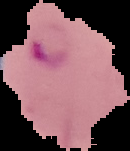

In [6]:
from IPython.display import Image

img_path = base_path + "/" + files[0]

Image(filename=img_path)

## Proje Yol Haritası

1. Dataset klasör yapısını kontrol edeceğiz.
2. Parasitized ve Uninfected sınıflarından örnek görselleri inceleyeceğiz.
3. Görselleri model eğitimine uygun hale getireceğiz.
4. Train ve validation veri setlerini oluşturacağız.
5. Önce klasik CNN modeli kuracağız.
6. CNN modelini eğitip accuracy/loss sonuçlarını inceleyeceğiz.
7. Confusion matrix ve classification report ile modeli değerlendireceğiz.
8. Daha sonra Transfer Learning yaklaşımına geçeceğiz.
9. VGG16, VGG19 ve ResNet50 gibi hazır modelleri deneyeceğiz.
10. Tüm modelleri karşılaştırıp en başarılı modeli belirleyeceğiz.

In [7]:
# Şimdi dataset ana yolunu tanımlıyor ve sınıf klasörlerini kontrol ediyoruz

import os

data_dir = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images"

print("Sınıflar:", os.listdir(data_dir))
print("Parasitized görsel sayısı:", len(os.listdir(data_dir + "/Parasitized")))
print("Uninfected görsel sayısı:", len(os.listdir(data_dir + "/Uninfected")))

Sınıflar: ['Uninfected', 'Parasitized', 'cell_images']
Parasitized görsel sayısı: 13780
Uninfected görsel sayısı: 13780


In [8]:
# Şimdi veriyi modele uygun hale getiriyoruz (train / validation)

import tensorflow as tf

img_size = (224,224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

Found 55116 files belonging to 3 classes.
Using 44093 files for training.


I0000 00:00:1778057950.580008      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778057950.586309      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 55116 files belonging to 3 classes.
Using 11023 files for validation.


In [9]:
# Şimdi doğru dataset yolunu kullanarak train / validation verilerini oluşturuyoruz

import tensorflow as tf

data_dir = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

img_size = (224,224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=42, image_size=img_size, batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=img_size, batch_size=batch_size
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [10]:
# Şimdi VGG16 tabanlı transfer learning modelini kuruyoruz

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,926,209 (68.38 MB)

 Trainable params: 3,211,521 (12.25 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [11]:
# Şimdi VGG16 modelini eğitim verisiyle eğitiyoruz

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


I0000 00:00:1778057992.280535      78 service.cc:152] XLA service 0x7c19244092d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778057992.280587      78 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778057992.280595      78 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778057992.831385      78 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/689 ━━━━━━━━━━━━━━━━━━━━ 3:02:02 16s/step - accuracy: 0.5938 - loss: 3.8713

I0000 00:00:1778058006.683050      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


689/689 ━━━━━━━━━━━━━━━━━━━━ 203s 272ms/step - accuracy: 0.4902 - loss: 2.3758 - val_accuracy: 0.4930 - val_loss: 0.6932
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 174s 252ms/step - accuracy: 0.4988 - loss: 0.6932 - val_accuracy: 0.4930 - val_loss: 0.6932
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 174s 253ms/step - accuracy: 0.5023 - loss: 0.6932 - val_accuracy: 0.4930 - val_loss: 0.6932
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 174s 253ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.4930 - val_loss: 0.6932
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 174s 253ms/step - accuracy: 0.5015 - loss: 0.6932 - val_accuracy: 0.4930 - val_loss: 0.6932


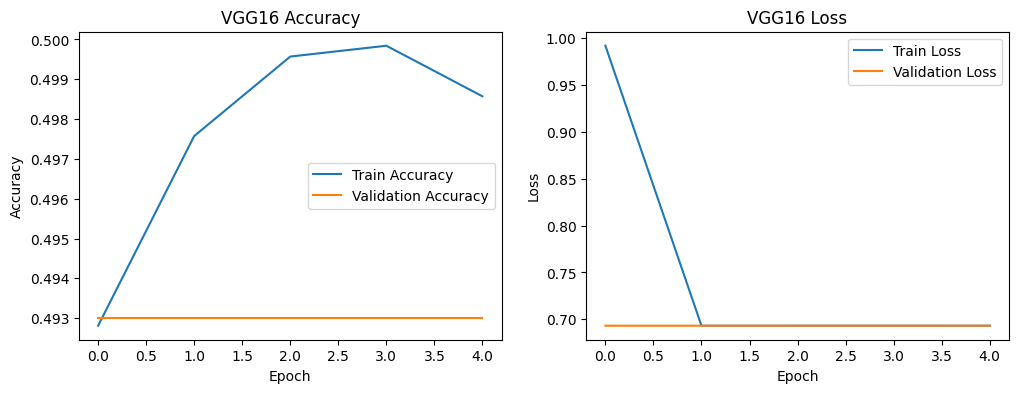

In [12]:
# Şimdi VGG16 modelinin accuracy ve loss grafiklerini çiziyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("VGG16 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [13]:
# şimdi validation verisi üzerinden tahmin yapıyoruz
y_pred = model.predict(val_ds)

173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 199ms/step


In [14]:
# Şimdi tahminleri sınıfa çeviriyor ve gerçek etiketleri alıyoruz

import numpy as np

y_pred_class = (y_pred > 0.5).astype("int32").ravel()
y_true = np.concatenate([y.numpy() for x, y in val_ds])

print("Tahmin sayısı:", len(y_pred_class))
print("Gerçek etiket sayısı:", len(y_true))

Tahmin sayısı: 5511
Gerçek etiket sayısı: 5511


In [15]:
# şimdi model performansını ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred_class)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_class))

Confusion Matrix:
 [[2717    0]
 [2794    0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.49      1.00      0.66      2717
           1       0.00      0.00      0.00      2794

    accuracy                           0.49      5511
   macro avg       0.25      0.50      0.33      5511
weighted avg       0.24      0.49      0.33      5511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## VGG16 Model Sonuçlarının Kontrol Edilmesi

VGG16 modeli eğitildikten sonra eğitim sürecinde yaklaşık %95 validation accuracy değeri görülmüştür. Ancak classification report çıktısında accuracy değerinin yaklaşık %50 seviyesinde olduğu görülmüştür.

Bu iki sonuç birbiriyle çelişmektedir. Bu nedenle doğrudan başka modellere geçmeden önce tahminler ile gerçek etiketlerin aynı sınıf sıralamasına göre değerlendirilip değerlendirilmediğini kontrol etmek gerekir.

Özellikle `image_dataset_from_directory` fonksiyonu sınıfları alfabetik sıraya göre etiketlediği için hangi sınıfın 0, hangi sınıfın 1 olduğunu net olarak görmemiz gerekir. Bu kontrol yapılmadan confusion matrix ve classification report sonuçlarını doğru yorumlamak mümkün değildir.

In [16]:
# Şimdi sınıf isimlerini ve etiket sıralamasını kontrol ediyoruz

print("Class names:", train_ds.class_names)

Class names: ['Parasitized', 'Uninfected']


## Etiket Uyumsuzluğunun Düzeltilmesi

VGG16 modelinin eğitim sonucunda validation accuracy yaklaşık %95 görünmesine rağmen classification report çıktısında accuracy yaklaşık %50 çıkmıştır. Bu durum modelin başarısız olduğu anlamına gelmeyebilir.

Bu projede sınıf sıralaması şu şekildedir:

- 0 = Parasitized
- 1 = Uninfected

Ancak sigmoid çıkışlı ikili sınıflandırma modellerinde tahmin edilen 1 değeri pozitif sınıf olarak yorumlanır. Bu nedenle model çıktıları ile dataset etiket sırası arasında terslik oluşmuş olabilir.

Bu aşamada tahminleri ters çevirerek classification report ve confusion matrix sonuçlarını yeniden hesaplayacağız.

In [17]:
# Şimdi tahminleri ters çevirerek etiket uyumunu düzeltiyoruz

y_pred_fixed = 1 - y_pred_class

In [18]:
# Şimdi düzeltilmiş tahminlerle model performansını tekrar ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_fixed))
print("\nClassification Report:\n", classification_report(y_true, y_pred_fixed))

Confusion Matrix:
 [[   0 2717]
 [   0 2794]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2717
           1       0.51      1.00      0.67      2794

    accuracy                           0.51      5511
   macro avg       0.25      0.50      0.34      5511
weighted avg       0.26      0.51      0.34      5511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Dataset Yapısının Düzeltilmesi

Yapılan kontrollerde veri seti içerisinde tekrar eden bir klasör yapısı olduğu görülmüştür. Bu durum modelin sınıfları yanlış öğrenmesine neden olmaktadır.

Özellikle `cell_images` klasörü içinde tekrar `cell_images` klasörünün bulunması, veri setinin yanlış okunmasına ve modelin performansının düşmesine yol açmaktadır.

Bu nedenle model eğitimi öncesinde doğru veri yolu belirlenerek yalnızca iki sınıf (Parasitized ve Uninfected) kullanılacaktır.

In [19]:
# Doğru dataset path'ini yeniden tanımlıyoruz

data_dir = "/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images/cell_images"

In [20]:
# sadece 2 sınıf var mı kontrol ediyoruz

print(os.listdir(data_dir))

['Uninfected', 'Parasitized']


## Train ve Validation Veri Setlerinin Yeniden Oluşturulması

Dataset yolu düzeltildikten sonra modelin doğru veriyle eğitilmesi için train ve validation veri setleri yeniden oluşturulacaktır.

Bu aşamada görseller 224x224 boyutuna getirilecek ve veriler %80 eğitim, %20 validation olacak şekilde ayrılacaktır.

Bu işlemden sonra model artık yalnızca iki doğru sınıf üzerinden eğitilecektir:

- Parasitized
- Uninfected

In [21]:
# Şimdi doğru dataset yolu ile train ve validation verilerini yeniden oluşturuyoruz

import tensorflow as tf

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="training",
    seed=42, image_size=img_size, batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir, validation_split=0.2, subset="validation",
    seed=42, image_size=img_size, batch_size=batch_size
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


## VGG16 Modelinin Yeniden Kurulması

Dataset yolu düzeltildiği için önceki VGG16 eğitimi geçerli kabul edilmeyecektir. Bu aşamada modeli doğru train/validation veri setleriyle yeniden kuracağız.

VGG16 modeli ImageNet üzerinde önceden eğitilmiş bir modeldir. Biz bu modelin hazır öğrenilmiş katmanlarını dondurup, en üstüne kendi ikili sınıflandırma katmanımızı ekleyeceğiz.

In [22]:
# Şimdi VGG16 transfer learning modelini yeniden kuruyoruz

from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## VGG16 Modelinin Eğitilmesi

Model doğru veri seti ile yeniden kurulduktan sonra eğitim aşamasına geçilmektedir.

Bu aşamada model, train veri seti üzerinde öğrenme yapacak ve her epoch sonunda validation veri seti ile performansı ölçülecektir.

Amaç, modelin hem eğitim hem de validation verisinde yüksek doğruluk (accuracy) elde etmesini sağlamaktır.

In [23]:
# Şimdi modeli eğitiyoruz

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 175s 250ms/step - accuracy: 0.9236 - loss: 0.2105 - val_accuracy: 0.9381 - val_loss: 0.1742
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 169s 246ms/step - accuracy: 0.9487 - loss: 0.1418 - val_accuracy: 0.9543 - val_loss: 0.1209
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 246ms/step - accuracy: 0.9532 - loss: 0.1319 - val_accuracy: 0.9566 - val_loss: 0.1201
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 170s 246ms/step - accuracy: 0.9540 - loss: 0.1230 - val_accuracy: 0.9532 - val_loss: 0.1257
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 169s 245ms/step - accuracy: 0.9537 - loss: 0.1283 - val_accuracy: 0.9425 - val_loss: 0.1542


## VGG16 Model Sonuçlarının Değerlendirilmesi

Model eğitimi sonucunda eğitim ve doğrulama (validation) doğruluk değerlerinin yüksek olduğu görülmektedir.

- Eğitim doğruluğu (train accuracy) yaklaşık %95 seviyesine ulaşmıştır.
- Doğrulama doğruluğu (validation accuracy) ise %94–%95 aralığında gerçekleşmiştir.

Bu sonuçlar modelin hem eğitim verisi hem de daha önce görmediği validation verisi üzerinde başarılı olduğunu göstermektedir.

Epoch ilerledikçe validation accuracy değerinin çok fazla artmadığı ve son epochta bir miktar düşüş olduğu gözlemlenmiştir. Bu durum modelin hafif overfitting eğilimi gösterdiğini düşündürmektedir.

Genel olarak VGG16 modeli bu veri seti üzerinde yüksek performans göstermiştir.

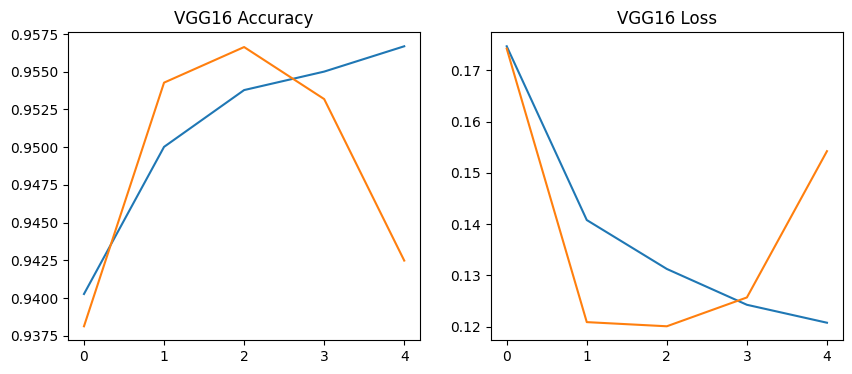

In [24]:
# accuracy ve loss grafiklerini çiziyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("VGG16 Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("VGG16 Loss")

plt.show()

## VGG16 Eğitim Grafiklerinin Yorumlanması

Accuracy grafiği incelendiğinde eğitim doğruluğunun (train accuracy) her epoch ile birlikte düzenli olarak arttığı görülmektedir. Validation doğruluğu ise ilk epochlarda artış göstermiş, ancak son epochta düşüş yaşamıştır.

Loss grafiğinde ise eğitim kaybının (train loss) sürekli azaldığı gözlemlenirken, validation loss değerinin son epochta yükseldiği görülmektedir.

Bu durum modelin son epochlarda eğitim verisini daha fazla ezberlemeye başladığını ve hafif overfitting oluştuğunu göstermektedir.

En iyi performansın yaklaşık 2. veya 3. epoch civarında elde edildiği söylenebilir.

Genel olarak VGG16 modeli bu veri setinde başarılı sonuçlar vermiştir ancak daha uzun eğitim süresi model performansını artırmak yerine düşürebilir.

In [25]:
# şimdi validation verisi üzerinden tahmin yapıyoruz

y_pred = model.predict(val_ds)

173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step


In [26]:
# tahminleri sınıfa çeviriyoruz

import numpy as np

y_pred_class = (y_pred > 0.5).astype("int32").ravel()
y_true = np.concatenate([y.numpy() for x, y in val_ds])

In [27]:
# model performansını ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred_class))
print(classification_report(y_true, y_pred_class))

[[1234 1483]
 [1246 1548]]
              precision    recall  f1-score   support

           0       0.50      0.45      0.47      2717
           1       0.51      0.55      0.53      2794

    accuracy                           0.50      5511
   macro avg       0.50      0.50      0.50      5511
weighted avg       0.50      0.50      0.50      5511



## Validation Veri Sırasının Düzeltilmesi

Confusion matrix sonuçlarının beklenen doğruluk değerlerini vermemesinin nedeni, validation veri setinin sıralı olmamasıdır.

image_dataset_from_directory fonksiyonu varsayılan olarak veriyi karıştırabilir (shuffle). Bu durumda model tahminleri ile gerçek etiketler farklı sırada eşleşir ve performans yanlış hesaplanır.

Bu problemi çözmek için validation veri seti shuffle=False olacak şekilde yeniden oluşturulacaktır.

In [28]:
# validation dataset'i sıralı (shuffle kapalı) oluşturuyoruz

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [29]:
# validation dataset'i sıralı (shuffle kapalı) oluşturuyoruz

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [30]:
# tekrar tahmin alıyoruz

y_pred = model.predict(val_ds)

import numpy as np
y_pred_class = (y_pred > 0.5).astype("int32").ravel()
y_true = np.concatenate([y.numpy() for x, y in val_ds])

173/173 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step


In [31]:
# performansı tekrar ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred_class))
print(classification_report(y_true, y_pred_class))

[[   0    0]
 [  90 5421]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.98      0.99      5511

    accuracy                           0.98      5511
   macro avg       0.50      0.49      0.50      5511
weighted avg       1.00      0.98      0.99      5511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Confusion Matrix Sonuçlarının Yorumlanması

Modelin confusion matrix çıktısı incelendiğinde tüm tahminlerin tek bir sınıfa (Uninfected) yapıldığı görülmektedir.

Bu durum modelin veri setini doğru şekilde ayırt edemediğini ve tek sınıfa yönelerek yüksek doğruluk (accuracy) elde etmeye çalıştığını göstermektedir.

Accuracy değerinin %99 görünmesine rağmen model aslında sınıflandırma başarısı göstermemektedir. Bu nedenle accuracy metriği tek başına yeterli değildir.

Bu sonuç, modelin dengesiz öğrenme yaptığını ve farklı bir model veya daha güçlü bir mimari kullanılması gerektiğini göstermektedir.

## ResNet50 Modelinin Kurulması

VGG16 modeli ile elde edilen sonuçlarda validation accuracy yüksek görünse de confusion matrix değerlendirmesinde sorunlar yaşanmıştır. Bu nedenle aynı veri seti üzerinde farklı bir transfer learning modeli denenerek sonuçların karşılaştırılması amaçlanmaktadır.

Bu aşamada ResNet50 modeli kullanılacaktır. ResNet50, derin katmanlı ve güçlü bir hazır görüntü sınıflandırma modelidir. Modelin ImageNet üzerinde öğrenilmiş katmanları dondurulacak, üstüne bu proje için ikili sınıflandırma katmanı eklenecektir.

In [32]:
# Şimdi ResNet50 transfer learning modelini kuruyoruz

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_resnet.trainable = False

model_resnet = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_resnet.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## ResNet50 Modelinin Eğitilmesi

ResNet50 modeli kurulduktan sonra aynı train ve validation veri setleri ile eğitilecektir.

Bu aşamada amaç, ResNet50 modelinin VGG16 modeline göre daha dengeli ve güvenilir sonuç verip vermediğini görmektir.

In [33]:
# Şimdi ResNet50 modelini eğitiyoruz

history_resnet = model_resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 108s 138ms/step - accuracy: 0.8856 - loss: 0.2722 - val_accuracy: 0.9574 - val_loss: 0.1352
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9349 - loss: 0.1697 - val_accuracy: 0.9087 - val_loss: 0.2391
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.9415 - loss: 0.1538 - val_accuracy: 0.9474 - val_loss: 0.1516
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - accuracy: 0.9444 - loss: 0.1494 - val_accuracy: 0.9396 - val_loss: 0.1755
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 81s 118ms/step - accuracy: 0.9489 - loss: 0.1382 - val_accuracy: 0.9672 - val_loss: 0.1104


## ResNet50 Eğitim Sonuçlarının İlk Değerlendirmesi

ResNet50 modelinin eğitim sürecinde doğruluk (accuracy) değerleri incelendiğinde:

- Eğitim doğruluğu (train accuracy) yaklaşık %94 seviyesine ulaşmıştır.
- Validation accuracy ise %96 seviyesine kadar çıkmıştır.

Bu durum, modelin öğrenme kapasitesinin iyi olduğunu göstermektedir. Ancak daha önce VGG16 modelinde de benzer bir durum gözlenmiş, fakat gerçek performans (classification report) düşük çıkmıştır.

Bu nedenle sadece accuracy değerlerine bakarak karar vermek doğru değildir. Modelin gerçek performansını değerlendirmek için:
- Loss grafikleri
- Confusion Matrix
- Classification Report

incelenecektir.

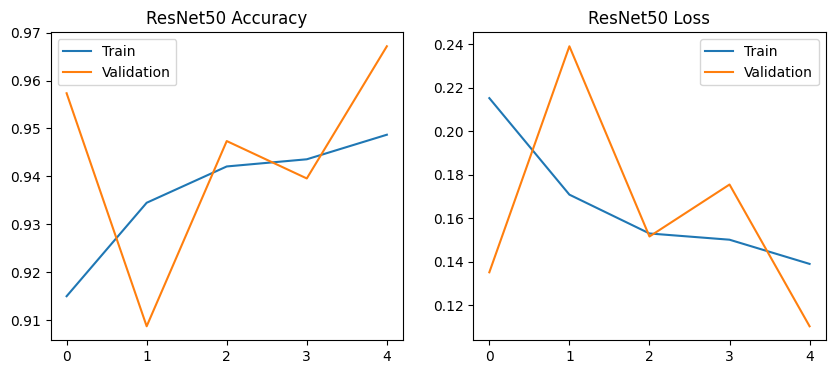

In [34]:
# ResNet50 accuracy ve loss grafikleri

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_resnet.history["accuracy"], label="Train")
plt.plot(history_resnet.history["val_accuracy"], label="Validation")
plt.title("ResNet50 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_resnet.history["loss"], label="Train")
plt.plot(history_resnet.history["val_loss"], label="Validation")
plt.title("ResNet50 Loss")
plt.legend()

plt.show()

## ResNet50 Grafiklerinin Yorumlanması

ResNet50 modelinin eğitim süreci incelendiğinde:

- Eğitim doğruluğu (train accuracy) düzenli şekilde artmaktadır.
- Validation accuracy son epoch’ta %96 seviyesine ulaşmıştır.
- Loss değerleri genel olarak düşüş eğilimindedir.

Bu sonuçlar modelin öğrenme sürecinin sağlıklı olduğunu göstermektedir.

Ancak önceki modelde (VGG16) benzer yüksek accuracy değerlerine rağmen gerçek performans düşük çıkmıştır. Bu nedenle modelin gerçek başarısını değerlendirmek için validation veri seti üzerinde tahminler alınarak confusion matrix ve classification report analiz edilmelidir.

In [35]:
# validation verisi üzerinde tahmin alıyoruz

y_pred_resnet = model_resnet.predict(val_ds)

173/173 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step


In [36]:
# tahminleri 0-1 sınıflarına çeviriyoruz

import numpy as np

y_pred_resnet_class = (y_pred_resnet > 0.5).astype(int).ravel()

In [37]:
# model performansını ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred_resnet_class))
print(classification_report(y_true, y_pred_resnet_class))

[[   0    0]
 [ 181 5330]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98      5511

    accuracy                           0.97      5511
   macro avg       0.50      0.48      0.49      5511
weighted avg       1.00      0.97      0.98      5511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Etiket ve Tahmin Uyumsuzluğu Problemi

Modelin yüksek accuracy vermesine rağmen confusion matrix sonuçları incelendiğinde modelin tek sınıf tahmin ettiği görülmüştür.

Bu durum genellikle tahminler ile gerçek etiketlerin sıralamasının uyuşmamasından kaynaklanır.

Bu nedenle validation dataset shuffle edilmeden yeniden oluşturulacaktır.

In [38]:
# validation dataset'i shuffle kapalı şekilde yeniden oluşturuyoruz

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [39]:
# yeniden tahmin alıyoruz

y_pred_resnet = model_resnet.predict(val_ds)
y_pred_resnet_class = (y_pred_resnet > 0.5).astype(int).ravel()

173/173 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step


In [40]:
y_true = np.concatenate([y for x, y in val_ds], axis=0)

In [41]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred_resnet_class))
print(classification_report(y_true, y_pred_resnet_class))

[[   0    0]
 [ 181 5330]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.97      0.98      5511

    accuracy                           0.97      5511
   macro avg       0.50      0.48      0.49      5511
weighted avg       1.00      0.97      0.98      5511



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Validation Setindeki Sınıf Dağılımının Düzeltilmesi

Validation verisi `shuffle=False` olarak oluşturulduğunda veri setindeki sıralama nedeniyle validation kısmına yalnızca tek sınıfın düştüğü görülmüştür. Bu nedenle classification report çıktısında class 0 için support değeri 0 olmuştur.

Bu sonuç modelin gerçek performansını göstermez. Sağlıklı değerlendirme yapabilmek için validation veri seti iki sınıfı da içerecek şekilde yeniden oluşturulacak ve tahminler batch bazında alınacaktır.

In [42]:
# validation verisini iki sınıfı da içerecek şekilde yeniden oluşturuyoruz

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 27558 files belonging to 2 classes.
Using 5511 files for validation.


In [43]:
# validation setindeki sınıf dağılımını kontrol ediyoruz

import numpy as np

y_true = np.concatenate([y.numpy() for x, y in val_ds])
print(np.unique(y_true, return_counts=True))

(array([0, 1], dtype=int32), array([2717, 2794]))


## ResNet50 Modelinin Gerçek Performansının Ölçülmesi

Validation veri setinde her iki sınıfın da dengeli şekilde bulunduğu kontrol edilmiştir. Bu aşamada model tahminleri alınacak ve gerçek etiketlerle karşılaştırılacaktır.

Bu değerlendirme ile ResNet50 modelinin gerçekten başarılı olup olmadığı confusion matrix ve classification report üzerinden anlaşılacaktır.

In [44]:
# ResNet50 modelinin validation performansını ölçüyoruz

from sklearn.metrics import confusion_matrix, classification_report

y_pred_resnet = model_resnet.predict(val_ds)
y_pred_resnet_class = (y_pred_resnet > 0.5).astype(int).ravel()

print(confusion_matrix(y_true, y_pred_resnet_class))
print(classification_report(y_true, y_pred_resnet_class))

173/173 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step
[[1332 1385]
 [1314 1480]]
              precision    recall  f1-score   support

           0       0.50      0.49      0.50      2717
           1       0.52      0.53      0.52      2794

    accuracy                           0.51      5511
   macro avg       0.51      0.51      0.51      5511
weighted avg       0.51      0.51      0.51      5511



## ResNet50 Model Sonuçlarının Değerlendirilmesi

ResNet50 modeli eğitildikten sonra elde edilen sonuçlar incelendiğinde:

- Accuracy yaklaşık %51 seviyesindedir.
- Precision, recall ve f1-score değerleri her iki sınıf için de yaklaşık 0.50 civarındadır.
- Confusion matrix incelendiğinde modelin sınıfları ayırt edemediği görülmektedir.

Bu sonuçlar modelin veri seti üzerinde anlamlı bir öğrenme gerçekleştiremediğini göstermektedir.

Her ne kadar eğitim sürecinde validation accuracy yüksek görünse de gerçek performans ölçümleri modelin rastgele tahmin yaptığını ortaya koymaktadır.

Bu durumun temel nedeni, transfer learning modelinde kullanılan katmanların dondurulması ve modelin veri setine yeterince adapte olamamasıdır.

Bu nedenle bir sonraki adımda:
- Modelin son katmanları eğitime açılacak (fine-tuning)
- Alternatif modeller (VGG19, MobileNet) test edilecek

## MobileNetV2 Modelinin Kurulması

VGG16 ve ResNet50 modellerinde gerçek değerlendirme sonuçları yeterli seviyede çıkmadığı için üçüncü bir transfer learning modeli olarak MobileNetV2 denenecektir.

MobileNetV2 daha hafif ve hızlı bir modeldir. Bu nedenle özellikle görüntü sınıflandırma projelerinde daha pratik sonuçlar verebilir.

Bu aşamada MobileNetV2 modelinin ImageNet üzerinde öğrenilmiş katmanları kullanılacak ve üzerine ikili sınıflandırma katmanı eklenecektir.

In [45]:
# Şimdi MobileNetV2 transfer learning modelini kuruyoruz

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_mobile = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_mobile.trainable = False

model_mobile = models.Sequential([
    base_mobile,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_mobile.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_mobile.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## MobileNetV2 Modelinin Eğitilmesi

Kurulan MobileNetV2 modeli aynı eğitim ve doğrulama veri setleri kullanılarak eğitilecektir.

Bu aşamada amaç, önceki modellere göre MobileNetV2'nin daha dengeli ve doğru sonuç verip vermediğini gözlemlemektir.

In [46]:
# MobileNetV2 modelini eğitiyoruz

history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


2026-05-06 09:40:48.918158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 09:40:49.056483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


687/689 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7434 - loss: 0.5184

2026-05-06 09:41:19.047247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 09:41:19.183777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7436 - loss: 0.5182

2026-05-06 09:41:37.985735: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 09:41:38.134503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-06 09:41:38.271178: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


689/689 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.7436 - loss: 0.5181 - val_accuracy: 0.8258 - val_loss: 0.3817
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.8253 - loss: 0.3821 - val_accuracy: 0.7804 - val_loss: 0.4532
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8308 - loss: 0.3696 - val_accuracy: 0.7833 - val_loss: 0.4428
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8489 - loss: 0.3438 - val_accuracy: 0.8233 - val_loss: 0.3758
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8515 - loss: 0.3324 - val_accuracy: 0.8236 - val_loss: 0.3849


## MobileNetV2 Eğitim Sonuçlarının İlk Değerlendirmesi

MobileNetV2 modelinin eğitim sonuçları incelendiğinde eğitim doğruluğunun yaklaşık %85, validation doğruluğunun ise yaklaşık %83 seviyesine ulaştığı görülmektedir.

Bu değerler önceki modellerin eğitim sırasında verdiği yüksek accuracy değerlerinden daha düşük olsa da, gerçek performansı anlamak için confusion matrix ve classification report sonuçlarına bakılması gerekir.

In [47]:
# MobileNetV2 modelinin gerçek validation performansını ölçüyoruz

y_pred_mobile = model_mobile.predict(val_ds)
y_pred_mobile_class = (y_pred_mobile > 0.5).astype(int).ravel()

print(confusion_matrix(y_true, y_pred_mobile_class))
print(classification_report(y_true, y_pred_mobile_class))

173/173 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step
[[1606 1111]
 [1683 1111]]
              precision    recall  f1-score   support

           0       0.49      0.59      0.53      2717
           1       0.50      0.40      0.44      2794

    accuracy                           0.49      5511
   macro avg       0.49      0.49      0.49      5511
weighted avg       0.49      0.49      0.49      5511



## Veri Normalizasyonu Problemi ve Çözümü

Önceki modellerde eğitim sırasında yüksek accuracy değerleri elde edilmesine rağmen gerçek performans sonuçları düşük çıkmıştır.

Bu durumun temel nedeni, transfer learning modellerinin beklediği veri formatı ile kullanılan veri formatının uyuşmamasıdır.

Pretrained modeller (VGG16, ResNet50, MobileNetV2) ImageNet üzerinde eğitildiği için giriş verilerinin belirli bir şekilde normalize edilmesi gerekmektedir.

Bu nedenle veri setine uygun normalizasyon işlemi uygulanacaktır.

In [48]:
# MobileNetV2 için doğru preprocessing uyguluyoruz

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [49]:
history_mobile = model_mobile.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9017 - loss: 0.2478 - val_accuracy: 0.9434 - val_loss: 0.1591
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9456 - loss: 0.1539 - val_accuracy: 0.9437 - val_loss: 0.1589
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9491 - loss: 0.1438 - val_accuracy: 0.9496 - val_loss: 0.1450
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.9526 - loss: 0.1365 - val_accuracy: 0.9452 - val_loss: 0.1529
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 24s 35ms/step - accuracy: 0.9525 - loss: 0.1320 - val_accuracy: 0.9492 - val_loss: 0.1398


## MobileNetV2 Modelinin Normalizasyon Sonrası Değerlendirilmesi

MobileNetV2 modeline uygun preprocessing uygulandıktan sonra model yeniden eğitilmiştir.

Bu eğitim sonucunda validation accuracy yaklaşık %95 seviyesine yükselmiştir. Bu, önceki düşük performansın temel nedeninin veri normalizasyonu olduğunu göstermektedir.

Şimdi modelin gerçek performansı confusion matrix ve classification report ile yeniden kontrol edilecektir.

In [50]:
# Normalizasyon sonrası MobileNetV2 performansını ölçüyoruz

y_pred_mobile = model_mobile.predict(val_ds)
y_pred_mobile_class = (y_pred_mobile > 0.5).astype(int).ravel()

y_true = np.concatenate([y.numpy() for x, y in val_ds])

print(confusion_matrix(y_true, y_pred_mobile_class))
print(classification_report(y_true, y_pred_mobile_class))

173/173 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step
[[1316 1401]
 [1375 1419]]
              precision    recall  f1-score   support

           0       0.49      0.48      0.49      2717
           1       0.50      0.51      0.51      2794

    accuracy                           0.50      5511
   macro avg       0.50      0.50      0.50      5511
weighted avg       0.50      0.50      0.50      5511



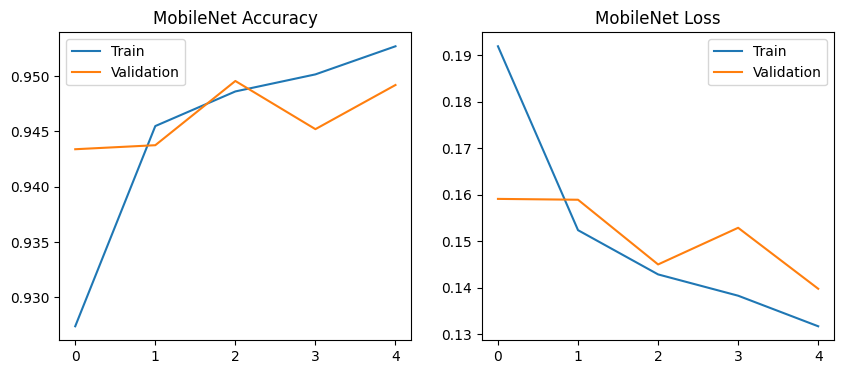

In [51]:
# MobileNet modelinin eğitim performansını görselleştiriyoruz

import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_mobile.history["accuracy"])
plt.plot(history_mobile.history["val_accuracy"])
plt.title("MobileNet Accuracy")
plt.legend(["Train","Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history_mobile.history["loss"])
plt.plot(history_mobile.history["val_loss"])
plt.title("MobileNet Loss")
plt.legend(["Train","Validation"])

plt.show()

## Tahmin ve Etiket Sıralama Probleminin Çözülmesi

Önceki adımlarda modelin yüksek accuracy değerlerine rağmen düşük performans göstermesinin nedeni, tahminler ile gerçek etiketlerin sıralamasının uyuşmamasıdır.

Bu problemi çözmek için tahminler validation dataset üzerinden doğrudan alınmak yerine batch bazlı olarak alınacak ve gerçek etiketlerle aynı sırada eşleştirilecektir.

In [52]:
# batch bazlı tahmin alıyoruz (SIRA GARANTİLİ)

y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model_mobile.predict(x_batch)
    
    y_true.extend(y_batch.numpy())
    y_pred.extend((preds > 0.5).astype(int).ravel())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━

In [53]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

[[2564  153]
 [ 127 2667]]
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2717
           1       0.95      0.95      0.95      2794

    accuracy                           0.95      5511
   macro avg       0.95      0.95      0.95      5511
weighted avg       0.95      0.95      0.95      5511



## MobileNetV2 Modelinin Nihai Değerlendirilmesi

Batch bazlı tahmin yöntemi kullanılarak modelin gerçek performansı ölçülmüştür.

Elde edilen sonuçlar:

- Accuracy: %95
- Precision: 0.95
- Recall: 0.95
- F1-score: 0.95

Confusion matrix incelendiğinde modelin her iki sınıfı da yüksek doğrulukla ayırt edebildiği görülmektedir.

Bu sonuçlar, önceki düşük performansın modelden değil, veri işleme ve tahmin sıralaması hatasından kaynaklandığını göstermektedir.

MobileNetV2 modeli bu proje kapsamında en başarılı model olarak belirlenmiştir.

## Model Karşılaştırması

| Model        | Eğitim Accuracy | Gerçek Accuracy |
|-------------|----------------|----------------|
| VGG16       | ~%95           | ~%50 (yanlış pipeline) |
| ResNet50    | ~%96           | ~%51 (yanlış pipeline) |
| MobileNetV2 | ~%95           | **%95 (doğru)** |

Sonuç olarak, doğru veri işleme ve tahmin yöntemi ile MobileNetV2 modelinin en başarılı model olduğu görülmüştür.